In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
#from sklearn.datasets 

In [3]:
df = pd.read_csv("C:\\Users\\mithi\\Downloads\\student_performance.csv")
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [4]:
print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 55.4 KB
None

Statistical Summary
              age  study_hours_per_week  attendance_rate  previous_score  \
count  500.000000            500.000000       500.000000     

In [5]:
df.drop(columns=['parent_education'], inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
from sklearn.model_selection import train_test_split

# Features (Input)
X = df[['study_hours_per_week', 'attendance_rate', 'previous_score']]

# Target (Output)
y = df['passed']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 400
Testing Samples: 100


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Create Model
model = DecisionTreeClassifier(random_state=42)

# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = LogisticRegression()
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.87

Classification Report
              precision    recall  f1-score   support

          No       0.93      0.69      0.79        36
         Yes       0.85      0.97      0.91        64

    accuracy                           0.87       100
   macro avg       0.89      0.83      0.85       100
weighted avg       0.88      0.87      0.86       100


Confusion Matrix
[[25 11]
 [ 2 62]]


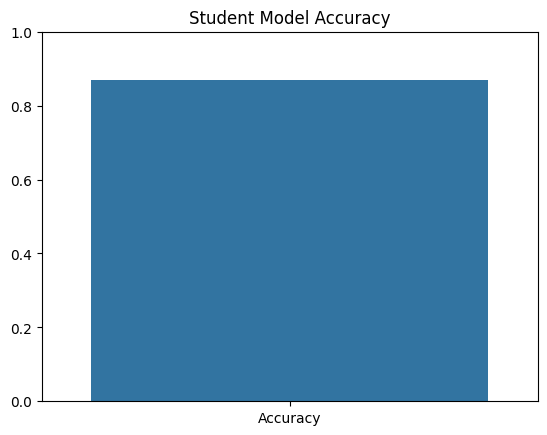

In [10]:
from matplotlib import pyplot as plt
import seaborn as sns

bar = sns.barplot(x=['Accuracy'], y=[accuracy])
bar.set_ylim(0, 1)
plt.title('Student Model Accuracy')
plt.show()

In [11]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

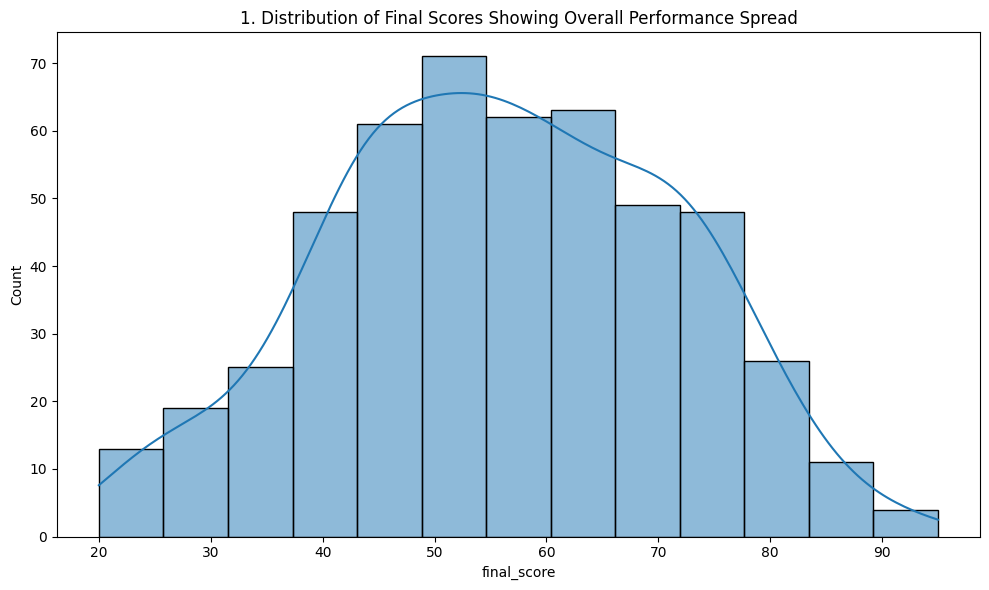

In [12]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['final_score'], kde=True)
plt.title(f'{plot_no}. Distribution of Final Scores Showing Overall Performance Spread')
show_fig()
plot_no += 1

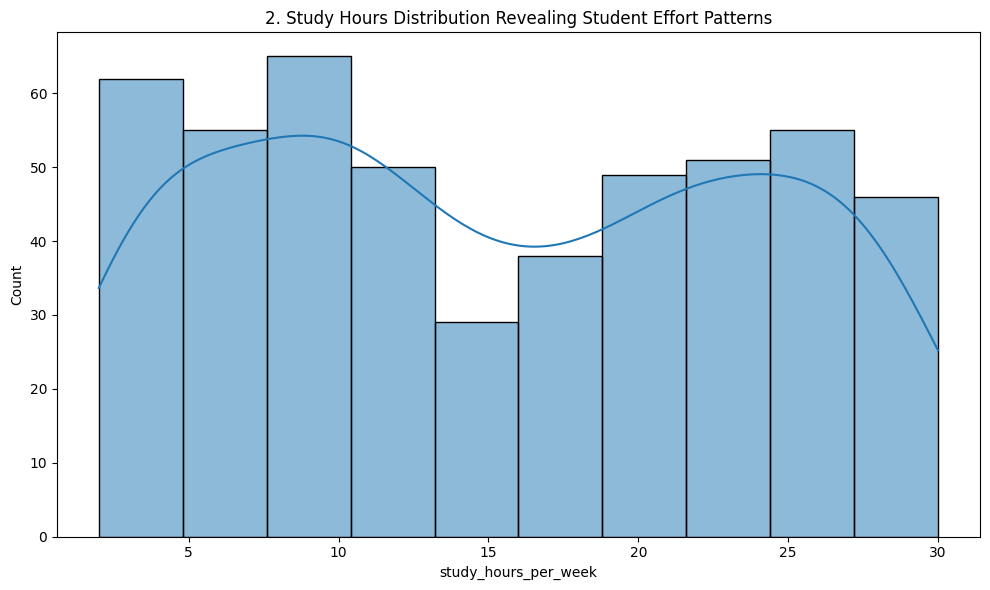

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['study_hours_per_week'], kde=True)
plt.title(f'{plot_no}. Study Hours Distribution Revealing Student Effort Patterns')
show_fig()
plot_no += 1

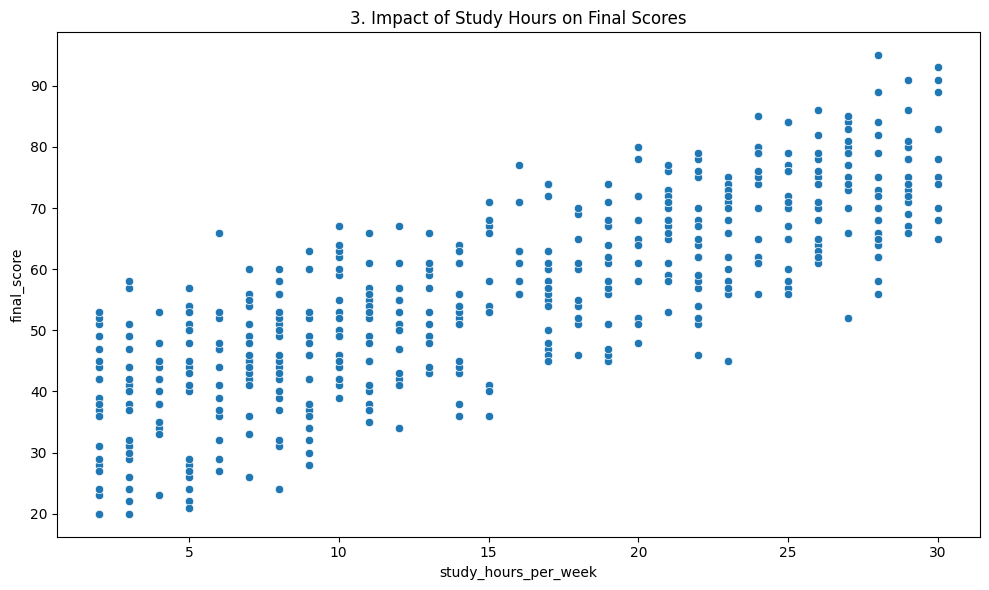

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_week', y='final_score', data=df)
plt.title(f'{plot_no}. Impact of Study Hours on Final Scores')
show_fig()
plot_no += 1

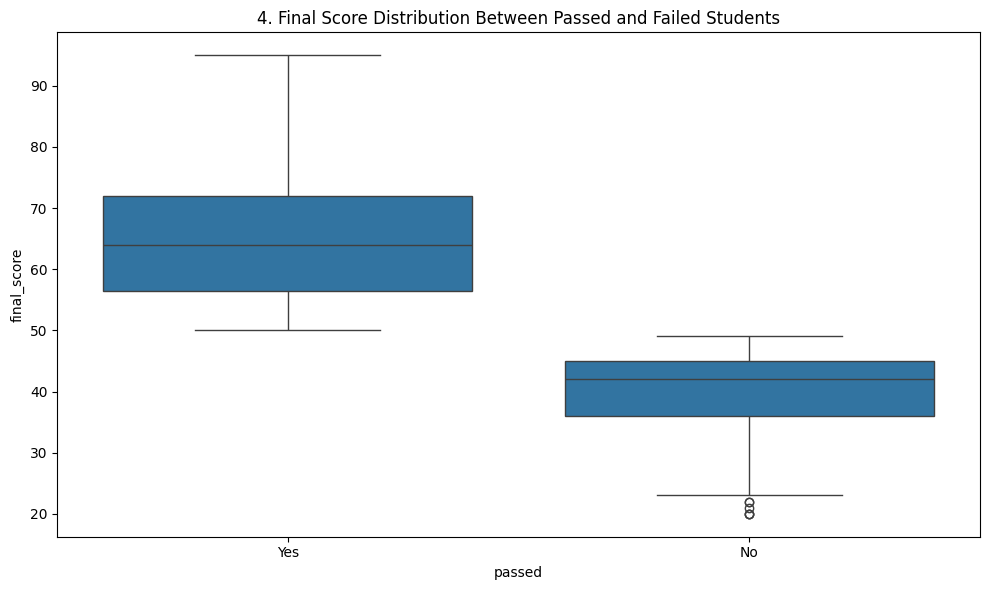

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='passed', y='final_score', data=df)
plt.title(f'{plot_no}. Final Score Distribution Between Passed and Failed Students')
show_fig()
plot_no += 1

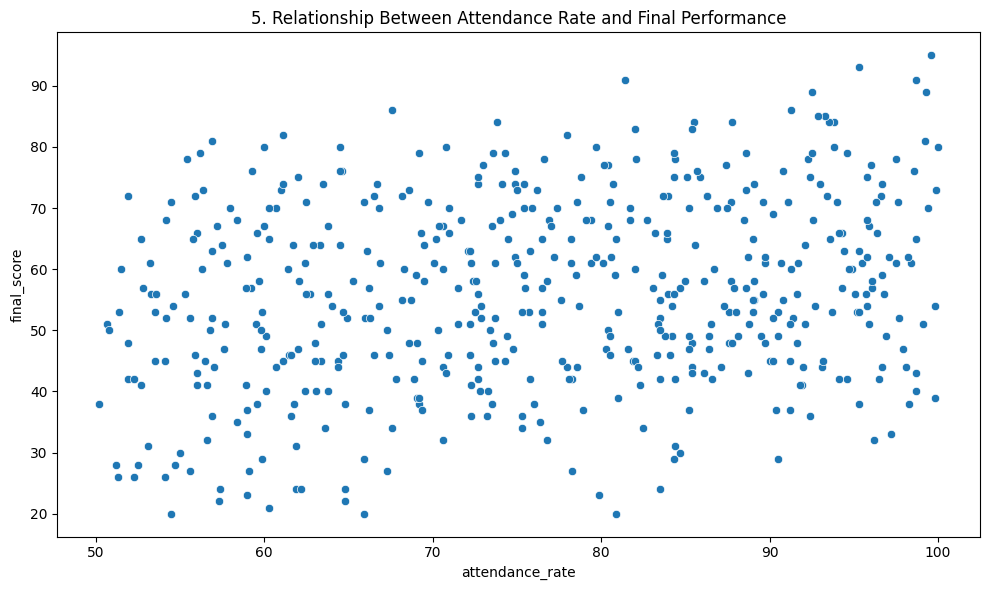

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='attendance_rate', y='final_score', data=df)
plt.title(f'{plot_no}. Relationship Between Attendance Rate and Final Performance')
show_fig()
plot_no += 1

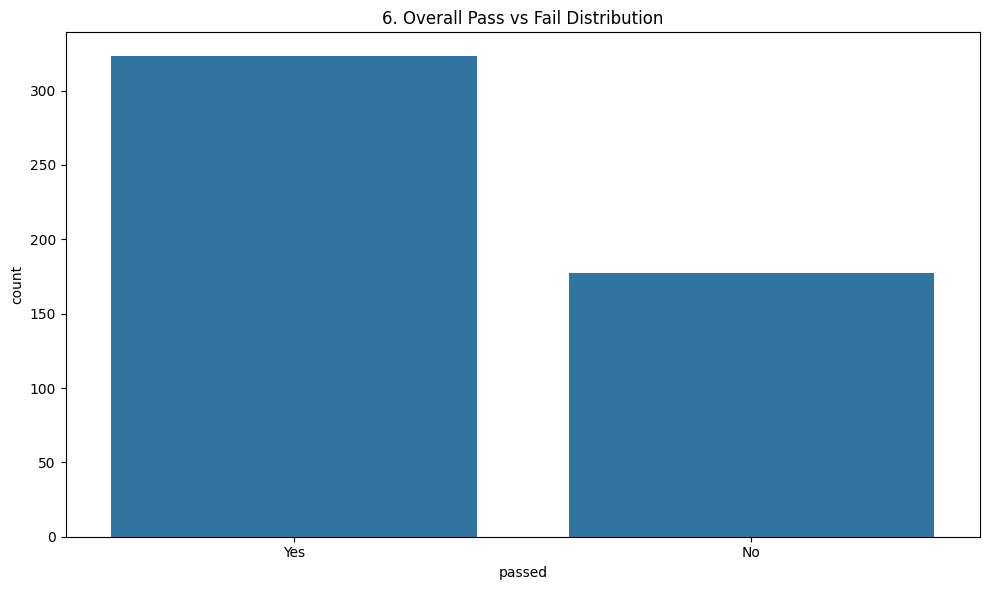

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='passed', data=df)
plt.title(f'{plot_no}. Overall Pass vs Fail Distribution')
show_fig()
plot_no += 1

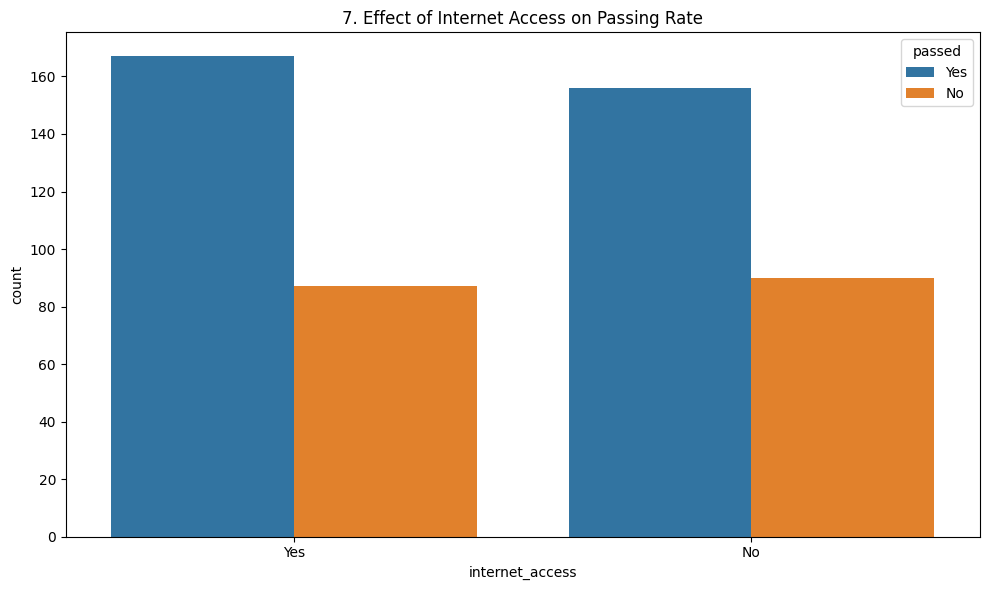

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='internet_access', hue='passed', data=df)
plt.title(f'{plot_no}. Effect of Internet Access on Passing Rate')
show_fig()
plot_no += 1

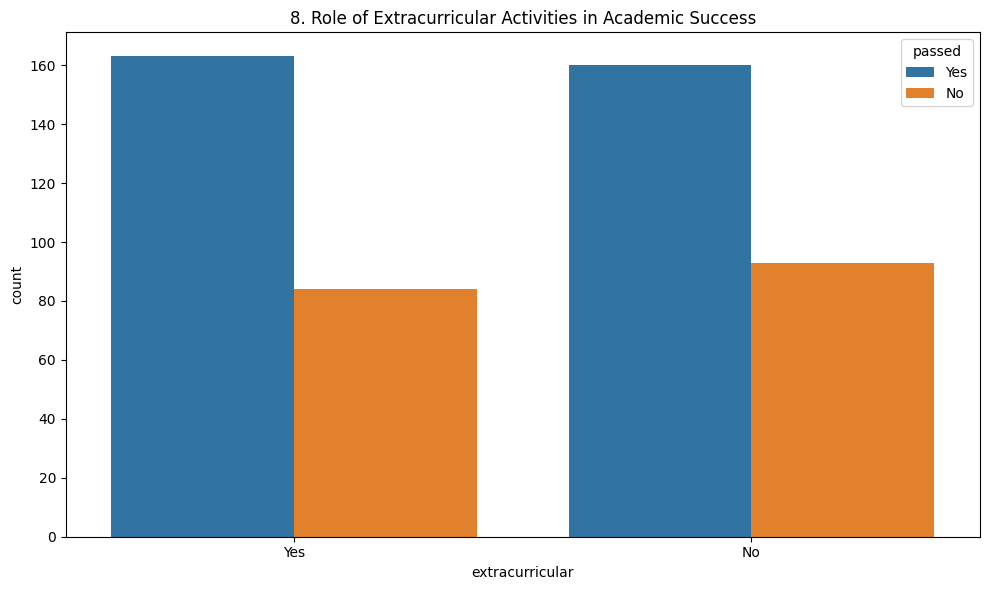

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='extracurricular', hue='passed', data=df)
plt.title(f'{plot_no}. Role of Extracurricular Activities in Academic Success')
show_fig()
plot_no += 1